# FRBCovariance — computing the DM covariance matrix

This notebook demonstrates how to use `FRBCovariance` to compute the mean dispersion measure (DM) and its covariance matrix for a catalogue of FRBs with known host redshifts.

### diagonal vs full matrix

| `diagonal` | computes | speed |
|---|---|---|
| `True`  | auto-variances only (`diag(C)`) | fast — simple loop |
| `False` | full N×N covariance matrix | slow — O(N²) Bessel integrals; shows a tqdm bar when `non_verbose=False` |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import astropy.coordinates as coord
import astropy.units as units
import cosmopower as cp

import frb_cov as frb

## 1  Load the cosmopower emulators

`FRBCovariance` relies on three neural-network emulators trained with cosmopower:
- **bias_emu** — electron bias contribution to the power spectrum
- **power_emu** — non-linear matter power spectrum
- **power_lin_emu** — linear matter power spectrum (optional but recommended)

In [2]:
bias_emu      = cp.cosmopower_NN(restore=True, restore_filename="../cosmopower/bias_sq_model")
power_emu     = cp.cosmopower_NN(restore=True, restore_filename="../cosmopower/pkmm_nonlin_model")
power_lin_emu = cp.cosmopower_NN(restore=True, restore_filename="../cosmopower/pkmm_lin_model")

## 2  Define a fiducial cosmology

`diagonal=True` (default) computes only the auto-variances and is fast.  
Use `diagonal=False` only when you need the full off-diagonal covariance (see section 5).

In [3]:
keys = [
    'sigma_8', 'h', 'omega_m', 'omega_b', 'omega_de',
    'w0', 'wa', 'ns', 'neff', 'm_nu', 'Tcmb0',
    'alpha_B', 'alpha_M', 'logTAGN', 'ks',
    'delta_gamma', 'diagonal', 'path_to_f_iGM',
]
values = [
    0.834, 0.674, 0.3, 0.05, 0.7,
    -1.0, 0.0, 0.963, 3.046, 0.06, 2.725,
    0.05, 0.05, 7.8, 0.1,
    0.0, True, '../data/figm',   # diagonal=True for fast evaluation
]
cosmo = dict(zip(keys, values))

## 3  Load and prepare the FRB catalogue

In [4]:
df = pd.read_csv("../data/00.New_FRB_Data.csv")
print(df.columns.tolist())
df.head()

['Name', 'RA', 'DEC', 'DMobs', 'DMmw', 'Redshift']


,Name,RA,DEC,DMobs,DMmw,Redshift
0,FRB20230708A,20:12:27.3,-55:21:22.6,411.51,50.0,0.10500
1,FRB20191106C,13:18:19.23,+42:59:58.97,332.20,25.0,0.10775
2,FRB20220914A,18:48:13.63,+73:20:12.9,631.28,55.2,0.11390
3,FRB20190608,22:16:04.74,-7:53:53.6,339.50,37.2,0.11778
4,FRB20190110C,16:37:16.43,+41:26:36.30,221.60,37.1,0.12244


In [5]:
DM_obs = df['DMobs'].values.astype(float)
DM_MW  = df['DMmw'].values.astype(float)
zet    = df['Redshift'].values.astype(float)

# Parse RA / Dec and convert to radians
ra  = coord.Angle(df['RA'].values,  unit=units.degree).radian - np.pi
dec = coord.Angle(df['DEC'].values, unit=units.degree).radian

# Remove duplicate redshifts and apply a basic quality cut
idx = np.sort(np.unique(zet, return_index=True)[1])
DM_obs, DM_MW, zet, ra, dec = DM_obs[idx], DM_MW[idx], zet[idx], ra[idx], dec[idx]
mask = np.logical_or(DM_obs < 1000, zet > 0.4)
DM_obs, DM_MW, zet, ra, dec = DM_obs[mask], DM_MW[mask], zet[mask], ra[mask], dec[mask]

print(f"{len(zet)} FRBs after cuts  |  z_max = {zet.max():.3f}")

69 FRBs after cuts  |  z_max = 1.354


In [6]:
# Pairwise angular separations on the sky
n = len(zet)
delta_theta = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if i != j:
            delta_theta[i, j] = np.arccos(
                np.clip(
                    np.sin(ra[i]) * np.sin(ra[j])
                    + np.cos(ra[i]) * np.cos(ra[j]) * np.cos(dec[i] - dec[j]),
                    -1.0, 1.0,
                )
            )

## 4  Mean DM and auto-variance (fast, diagonal=True)

`FRBCovariance` computes:
- `cov.DM` — mean LSS contribution to the DM for each FRB  
- `cov.covariance` — covariance matrix (only diagonal filled when `diagonal=True`)

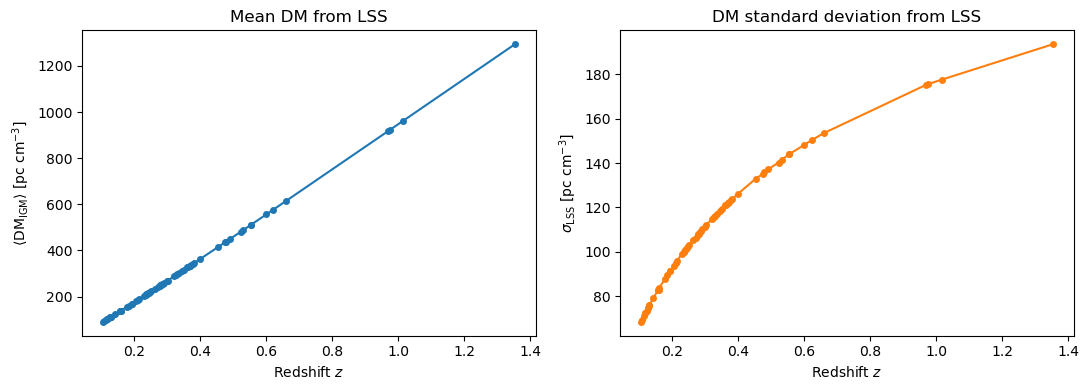

In [7]:
z_sorted = np.sort(zet)  # FRBCovariance expects ascending redshifts

cov = frb.FRBCovariance(
    cosmo,
    bias_emu,
    power_emu,
    z_sorted,
    delta_theta,
    flat_sky=True,
    plin_emu=power_lin_emu,
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(z_sorted, cov.DM, 'o-', ms=4)
ax.set_xlabel(r'Redshift $z$')
ax.set_ylabel(r'$\langle \mathrm{DM}_{\mathrm{IGM}} \rangle$ [pc cm$^{-3}$]')
ax.set_title('Mean DM from LSS')

ax = axes[1]
ax.plot(z_sorted, np.sqrt(np.diag(cov.covariance)), 'o-', ms=4, color='C1')
ax.set_xlabel(r'Redshift $z$')
ax.set_ylabel(r'$\sigma_{\rm LSS}$ [pc cm$^{-3}$]')
ax.set_title('DM standard deviation from LSS')

plt.tight_layout()
plt.show()

## 5  Full correlation matrix (diagonal=False)

Computing the full N×N matrix requires a Bessel-function integral for every FRB pair — O(N²) calls.  
Pass `non_verbose=False` to see the tqdm progress bar.

100%|██████████| 69/69 [01:06<00:00,  1.04it/s]


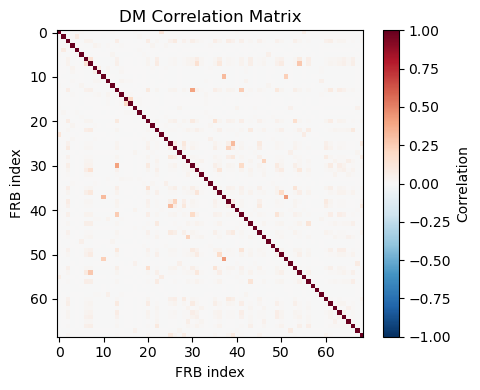

In [8]:
cosmo_full = dict(cosmo)
cosmo_full['diagonal'] = False

cov_full = frb.FRBCovariance(
    cosmo_full,
    bias_emu,
    power_emu,
    z_sorted,
    delta_theta,
    flat_sky=True,
    plin_emu=power_lin_emu,
    non_verbose=False,   # show tqdm progress bar
)

sigma = np.sqrt(np.diag(cov_full.covariance))
corr  = cov_full.covariance / np.outer(sigma, sigma)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
plt.colorbar(im, ax=ax, label='Correlation')
ax.set_title('DM Correlation Matrix')
ax.set_xlabel('FRB index')
ax.set_ylabel('FRB index')
plt.tight_layout()
plt.show()

## 6  Effect of baryonic feedback (log T_AGN)

We only need the auto-variances here so we keep `diagonal=True`.

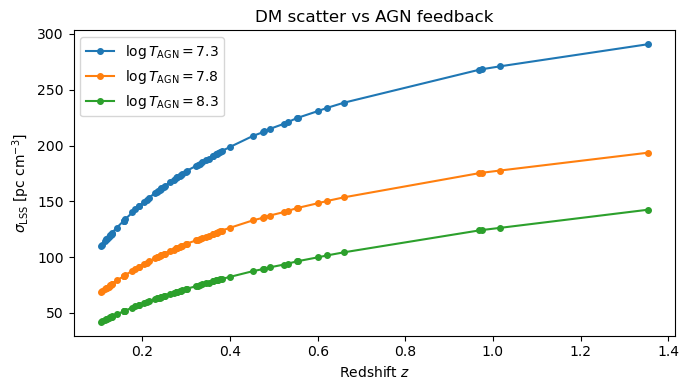

In [9]:
logTAGN_values = [7.3, 7.8, 8.3]

fig, ax = plt.subplots(figsize=(7, 4))
for logT, color in zip(logTAGN_values, ['C0', 'C1', 'C2']):
    cosmo_var = dict(cosmo)          # diagonal=True already set
    cosmo_var['logTAGN'] = logT
    c = frb.FRBCovariance(
        cosmo_var, bias_emu, power_emu, z_sorted, delta_theta,
        flat_sky=True, plin_emu=power_lin_emu,
    )
    ax.plot(z_sorted, np.sqrt(np.diag(c.covariance)), 'o-', ms=4,
            color=color, label=rf'$\log T_{{\rm AGN}}={logT}$')

ax.set_xlabel(r'Redshift $z$')
ax.set_ylabel(r'$\sigma_{\rm LSS}$ [pc cm$^{-3}$]')
ax.set_title('DM scatter vs AGN feedback')
ax.legend()
plt.tight_layout()
plt.show()